# (노트) Folium (1) - map, marker

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [시각화]

In [2]:
import numpy as np  # useful for many scientific computing in Python
import pandas as pd # primary data structure library
from IPython.display import HTML
import folium

### folium.Map

In [3]:
#!conda install -c conda-forge folium -y 
m = folium.Map(zoom_start=10,scrollWheelZoom=False)
m

- world_map는 map object 

`-` location 지정 

In [4]:
# create a Stamen Toner map of the world centered around North America
m = folium.Map(location=[35.836603154469884, 127.11406532500682],
               zoom_start=15,scrollWheelZoom=False)
m
# display map

`-` `tiles` 옵션
- "OpenStreetMap"
- "Stamen Terrain", "Stamen Toner", "Stamen Watercolor"
- "CartoDB positron", "CartoDB dark_matter"

In [5]:
m = folium.Map(location=[35.836603154469884, 127.11406532500682], 
               tiles='CartoDB positron', 
               zoom_start=15 ,
               scrollWheelZoom=False)
m

### folium.Marker

In [6]:
# from folium import FeatureGroup, LayerControl, Map, Marker
# Start by creating a Feature Group Map Base
m = folium.Map(
    location=[35.836603154469884, 127.11406532500682],
    zoom_start=14,
    scrollWheelZoom=False,
    tiles='CartoDB positron'
)
folium.Marker(
    location=[35.836603154469884, 127.11406532500682],
    popup='Home').add_to(m)

m

folium.Marker(
    location=[35.84694109945701, 127.12941011336521],
    icon=folium.Icon(color='red', # 배경색
                     icon_color='black', # 아이콘색 
                     icon='fa-university', 
                     angle=0,
                     prefix='fa'), # 이걸 써야지 아이콘이 보인다. 
    popup='JBNU').add_to(m)

m

`-` 조금 더 다양한 아이콘들을 추가하여 보자. 

In [7]:
m = folium.Map(
    location=[35.836603154469884, 127.11406532500682],
    zoom_start=14,
    scrollWheelZoom=False,
    tiles='CartoDB positron'
)
folium.Marker(
    location=[35.836603154469884, 127.11406532500682],
    popup='Home').add_to(m)
folium.Marker(
    location=[35.84694109945701, 127.12941011336521],
    icon=folium.Icon(color='red', # 배경색
                     icon_color='white', # 아이콘색 
                     icon='flag', 
                     angle=0,
                     prefix='fa'), # 이걸 써야지 아이콘이 보인다. 
    popup='JBNU').add_to(m)

m

`-` `icon = 'university'` 대신에 쓸만한 옵션들 

- icon='street-view'
- icon='tree'
- icon='plane'
- icon='bell'
- ... 

**https://getbootstrap.com/docs/3.3/components/**

`-` Circle Maker 

`-` DataFrame 넣기 

In [8]:
df=pd.DataFrame(data=[[2019,35],[2020,35],[2021,30]],columns=['Year','Enrollment'])
df.to_html()

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th></th>\n      <th>Year</th>\n      <th>Enrollment</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <th>0</th>\n      <td>2019</td>\n      <td>35</td>\n    </tr>\n    <tr>\n      <th>1</th>\n      <td>2020</td>\n      <td>35</td>\n    </tr>\n    <tr>\n      <th>2</th>\n      <td>2021</td>\n      <td>30</td>\n    </tr>\n  </tbody>\n</table>'

In [9]:
m = folium.Map(
    location=[35.836603154469884, 127.11406532500682],
    zoom_start=14,
    scrollWheelZoom=False,
    tiles='CartoDB positron'
)
folium.Marker(
    location=[35.836603154469884, 127.11406532500682],
    popup='Home').add_to(m)
folium.Marker(
    location=[35.84694109945701, 127.12941011336521],
    icon=folium.Icon(color='red', # 배경색
                     icon_color='white', # 아이콘색 
                     icon='flag', 
                     angle=0,
                     prefix='fa'), # 이걸 써야지 아이콘이 보인다. 
    popup="<h2> JBNU </h2><br>"+df.to_html()).add_to(m)

m

`-` 논리구조상 HTML오브젝트를 아무거나 넣을 수 있다. 

In [10]:
import base64
import matplotlib.pyplot as plt

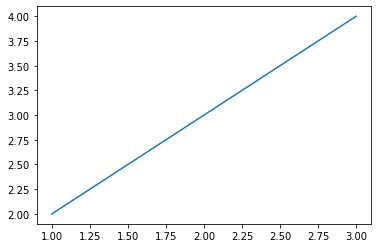

In [28]:
fig = plt.figure()
plt.plot([1,2,3],[2,3,4])
fig.savefig('2021-11-22-Folium(1)_temp.png')

In [29]:
_encoded = base64.b64encode(open('2021-11-22-Folium(1)_temp.png', 'rb').read())
_myhtml = '<img src="data:image/png;base64,{}">'.format
_iframe = folium.IFrame(_myhtml(_encoded.decode('UTF-8')), width=400, height=300)
_popup = folium.Popup(_iframe, max_width=2650)

In [30]:
m = folium.Map(
    location=[35.836603154469884, 127.11406532500682],
    zoom_start=14,
    scrollWheelZoom=False,
    tiles='CartoDB positron'
)
folium.Marker(
    location=[35.836603154469884, 127.11406532500682],
    popup='Home').add_to(m)
folium.Marker(
    location=[35.84694109945701, 127.12941011336521],
    icon=folium.Icon(color='red', # 배경색
                     icon_color='white', # 아이콘색 
                     icon='flag', 
                     angle=0,
                     prefix='fa'), # 이걸 써야지 아이콘이 보인다. 
    popup=_popup).add_to(m)
m

### folium.CircleMarker 

In [31]:
m = folium.Map(
    location=[35.836603154469884, 127.11406532500682],
    zoom_start=14,
    scrollWheelZoom=False,
    tiles='CartoDB positron'
)
folium.CircleMarker(
    [35.84694109945701, 127.12941011336521],
    popup='JNBU',
    radius=40,
    color=None,
    fill=True,
    fill_color='red',
    
).add_to(m)

In [32]:
m

`-` 그냥 지옴처럼 생각해도 괜찮아보임 